# Drone Control via STREL — Policy Gradient with Differentiable Dynamics

This notebook trains an MLP policy by directly differentiating through the known dynamics and the STL robustness signal:
- Differentiable rollout through `step_dynamics_batched`
- STL robustness computed via `spec.quantitative`
- Loss = `-mean_robustness + action_reg_weight * action_reg`
- No value network, no replay buffer, no lambda returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

from training.trainer import train_policy_gradient

## Hyperparameters

In [2]:
# Scenario
grid_side = 6
n_bases = 1
n_drones = 1
n_feat = 6

# Training loop
T_total = 70
n_iterations = 1000
batch_size = 64
mini_batch_size = 64   # gradient accumulation: batch_size / mini_batch_size steps

# Policy architecture
policy_type = "ego"   # "mlp", "ego", "attention"
policy_hidden = 32          # EgoDronePolicy default is 32 (vs 128 for mlp)

# Optimizer
lr = 3e-4
grad_clip = 1.0
action_reg_weight = 1e-2

# Manual step LR schedule
lr_schedule = {
    0:   3e-4,
    500: 5e-5,
}

# Truncated BPTT
bptt_k = 10

# Asymmetric state drift penalty
drift_weight = 5.0

# Smooth STL annealing
smooth_beta_start = 1.0
smooth_beta_end   = 100.0
smooth_beta_anneal_iters = 300

# Exploration noise
exploration_std = 0.01
use_exploration_annealing = True
exploration_std_start = 0.2
exploration_std_end = 0.001
exploration_anneal_iters = 500

# Initial drone position: sampled uniformly from [init_pos_min, init_pos_max]
init_pos_min = 1.0
init_pos_max = 6.0

# Resume / checkpoint
use_resume_checkpoint = False
resume_checkpoint_path = "policy_ego_checkpoint.pt"
save_checkpoint_path = "policy_ego_checkpoint.pt"
save_best_checkpoint_path = "policy_ego_best.pt"

device = 'auto'  # 'auto', 'cpu', 'cuda'


## Pretrained Policy (optional)

Set `load_pretrained = True` to skip training and load a saved policy instead.

In [3]:
from policy.attention_policy import DroneAttentionPolicy
from policy.mlp_policy import DroneMLPPolicy, EgoDronePolicy

load_pretrained = False
pretrained_path = "policy_ego_pretrained.pt"

if load_pretrained:
    _dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if policy_type == "mlp":
        policy = DroneMLPPolicy(
            n_drones=n_drones,
            n_bases=n_bases,
            n_feat=n_feat,
            hidden=policy_hidden,
            out_channels=2,
            action_scale=2.0,
        ).to(_dev)
    elif policy_type == "ego":
        policy = EgoDronePolicy(
            hidden=policy_hidden,
            action_scale=2.0,
        ).to(_dev)
    elif policy_type == "attention":
        policy = DroneAttentionPolicy(
            n_feat=n_feat,
            action_scale=2.0,
            d=16,
            n_latent=4,
            n_heads=2
        ).to(_dev)
    else:
        raise ValueError("policy_type must be one of: 'mlp', 'ego', 'attention'.")

    print(f"Policy parameters: {sum(p.numel() for p in policy.parameters()):,}")
    policy.load_state_dict(torch.load(pretrained_path, map_location=_dev, weights_only=True))
    policy.eval()
    history = None
    print(f"Loaded pretrained {policy_type} policy from '{pretrained_path}'")
else:
    print("load_pretrained=False — will train from scratch in the next cell.")


load_pretrained=False — will train from scratch in the next cell.


## Training

In [4]:
checkpoint_path = resume_checkpoint_path if use_resume_checkpoint else None

anneal_start = exploration_std_start if use_exploration_annealing else None
anneal_end = exploration_std_end if use_exploration_annealing else None
anneal_iters = exploration_anneal_iters if use_exploration_annealing else None

policy, history = train_policy_gradient(
    grid_side=grid_side,
    n_bases=n_bases,
    n_drones=n_drones,
    n_feat=n_feat,
    T_total=T_total,
    n_iterations=n_iterations,
    batch_size=batch_size,
    mini_batch_size=mini_batch_size,
    action_clip=2.0,
    policy_type=policy_type,
    policy_hidden=policy_hidden,
    lr=lr,
    lr_schedule=lr_schedule,
    grad_clip=grad_clip,
    action_reg_weight=action_reg_weight,
    bptt_k=bptt_k,
    drift_weight=drift_weight,
    smooth_beta_start=smooth_beta_start,
    smooth_beta_end=smooth_beta_end,
    smooth_beta_anneal_iters=smooth_beta_anneal_iters,
    exploration_std=exploration_std,
    exploration_std_start=anneal_start,
    exploration_std_end=anneal_end,
    exploration_anneal_iters=anneal_iters,
    init_pos_min=init_pos_min,
    init_pos_max=init_pos_max,
    checkpoint_path=checkpoint_path,
    save_checkpoint_path=save_checkpoint_path,
    save_best_checkpoint_path=save_best_checkpoint_path,
    device=device,
    show_progress=True,
    return_history=True,
)

stats = pd.DataFrame(history['stats'])

Policy: ego | params: 1,314
LR schedule: [(0, 0.0003), (500, 5e-05)]
Smooth STL: beta 1.0 → 100.0 over 300 iters


Policy Gradient Training:   0%|          | 0/1000 [00:00<?, ?iter/s]

In [5]:
# # Save policy to disk
# policy_path = "policy_1_ego.pt"
# torch.save(policy.state_dict(), policy_path)
# print(f"Policy saved to '{policy_path}'")

## Training Curves

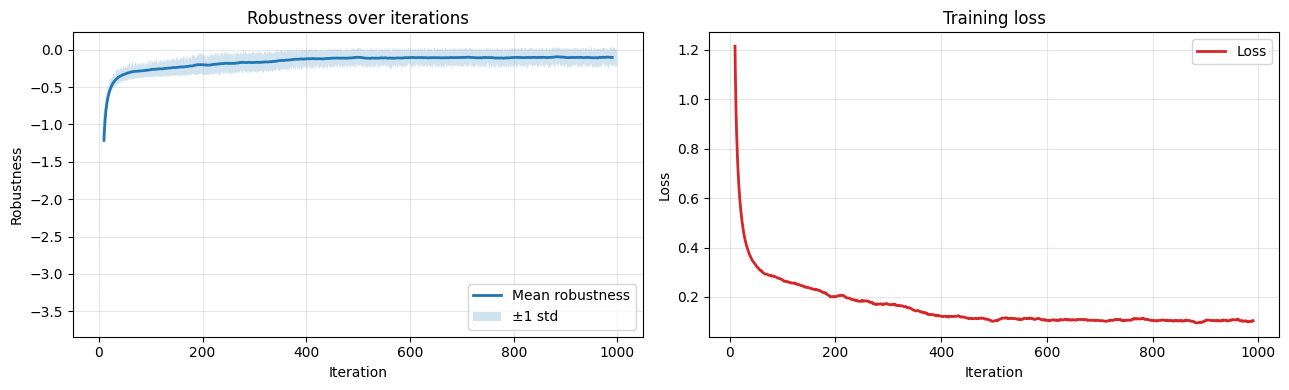

In [5]:
if history is not None:
    stats = pd.DataFrame(history['stats'])
    iters = np.arange(len(stats['mean']))

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))

    ax[0].plot(iters, stats['mean'].rolling(window=20, center=True).mean(), label='Mean robustness', lw=2)
    ax[0].fill_between(
        iters,
        np.array(stats['mean']) - np.array(stats['std']),
        np.array(stats['mean']) + np.array(stats['std']),
        alpha=0.2, label='±1 std',
    )
    ax[0].set_title('Robustness over iterations')
    ax[0].set_xlabel('Iteration')
    ax[0].set_ylabel('Robustness')
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    ax[1].plot(iters, stats['loss'].rolling(window=20, center=True).mean(), color='tab:red', lw=2, label='Loss')
    ax[1].set_title('Training loss')
    ax[1].set_xlabel('Iteration')
    ax[1].set_ylabel('Loss')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history available (pretrained policy loaded).")

In [ ]:
# Save policy model (weights only, for inference)
torch.save(policy.state_dict(), "policy_ego.pt")
print("Policy model saved to 'policy_ego.pt'")
print(f"Full training checkpoint path: {save_checkpoint_path}")


Policy model saved to 'policy_1.pt'
Full training checkpoint path: policy_checkpoint.pt


## Best vs Worst Episode

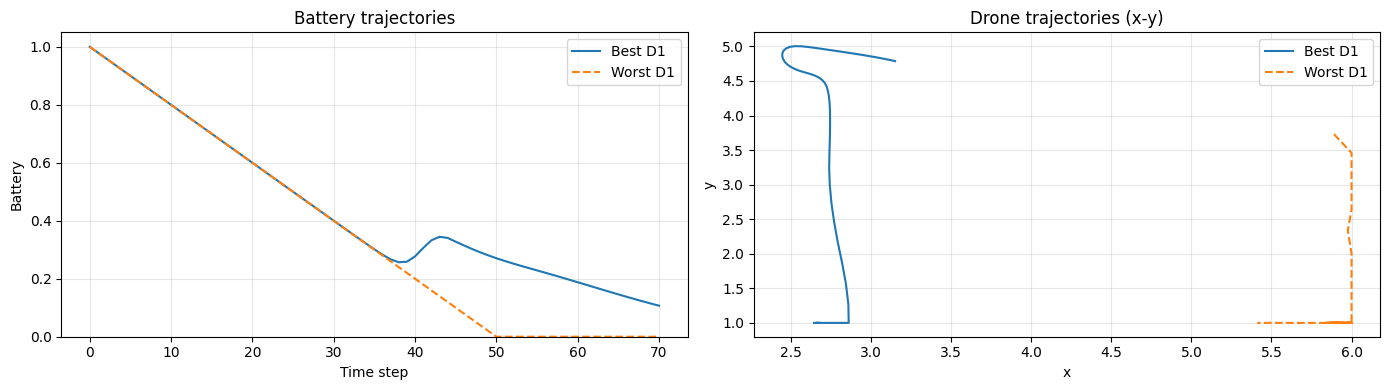

In [6]:
if history is not None:
    def traj_to_np(traj):
        return torch.stack(traj).permute(1, 2, 0).cpu().numpy()

    best_data = traj_to_np(history['best']['trajectory'])
    worst_data = traj_to_np(history['worst']['trajectory'])
    n_drones_run = int(history['config'].get('n_drones', 1))
    drone_idxs = list(range(best_data.shape[0] - n_drones_run, best_data.shape[0]))

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    for i, idx in enumerate(drone_idxs):
        ax[0].plot(best_data[idx, 4, :], label=f'Best D{i+1}')
        ax[0].plot(worst_data[idx, 4, :], linestyle='--', label=f'Worst D{i+1}')
    ax[0].set_title('Battery trajectories')
    ax[0].set_xlabel('Time step')
    ax[0].set_ylabel('Battery')
    ax[0].set_ylim(0, 1.05)
    ax[0].grid(alpha=0.3)
    ax[0].legend()

    for i, idx in enumerate(drone_idxs):
        ax[1].plot(best_data[idx, 0, :], best_data[idx, 1, :], label=f'Best D{i+1}')
        ax[1].plot(worst_data[idx, 0, :], worst_data[idx, 1, :], linestyle='--', label=f'Worst D{i+1}')
    ax[1].set_title('Drone trajectories (x-y)')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].grid(alpha=0.3)
    ax[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history available (pretrained policy loaded).")